<a href="https://colab.research.google.com/github/prachikadyan/prachikadyan/blob/main/Customer_Segmentation_%26_Credit_Risk_Analysis_using_Retail_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [ ]:
df = pd.read_csv('online_retail.csv')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
print(df.columns)

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


In [ ]:
df = df.dropna()
df = df[df['Quantity'] > 0]

In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
customer_data = df.groupby('CustomerID')['Revenue'].sum().reset_index()

In [ ]:
customer_data['Segment'] = pd.qcut(
    customer_data['Revenue'],
    3,
    labels=['Low Value','Medium Value','High Value']
)

In [ ]:
def risk_level(x):
    if x > 5000:
        return 'Low Risk'
    elif x > 2000:
        return 'Medium Risk'
    else:
        return 'High Risk'

customer_data['Risk'] = customer_data['Revenue'].apply(risk_level)

In [ ]:
customer_data = customer_data.sort_values(by='Revenue', ascending=False)

customer_data['Cumulative %'] = (
    customer_data['Revenue'].cumsum() / customer_data['Revenue'].sum()
)

customer_data.head()

,CustomerID,Revenue,Segment,Risk,Cumulative %
1690,14646.0,280206.02,High Value,Low Risk,0.031444
4202,18102.0,259657.30,High Value,Low Risk,0.060581
3729,17450.0,194550.79,High Value,Low Risk,0.082413
3009,16446.0,168472.50,High Value,Low Risk,0.101318
1880,14911.0,143825.06,High Value,Low Risk,0.117457


In [ ]:
top_customers = customer_data.head(10)
top_customers

,CustomerID,Revenue,Segment,Risk,Cumulative %
1690,14646.0,280206.02,High Value,Low Risk,0.031444
4202,18102.0,259657.30,High Value,Low Risk,0.060581
3729,17450.0,194550.79,High Value,Low Risk,0.082413
3009,16446.0,168472.50,High Value,Low Risk,0.101318
1880,14911.0,143825.06,High Value,Low Risk,0.117457
55,12415.0,124914.53,High Value,Low Risk,0.131475
1334,14156.0,117379.63,High Value,Low Risk,0.144647
3772,17511.0,91062.38,High Value,Low Risk,0.154865
2703,16029.0,81024.84,High Value,Low Risk,0.163958
0,12346.0,77183.60,High Value,Low Risk,0.172619


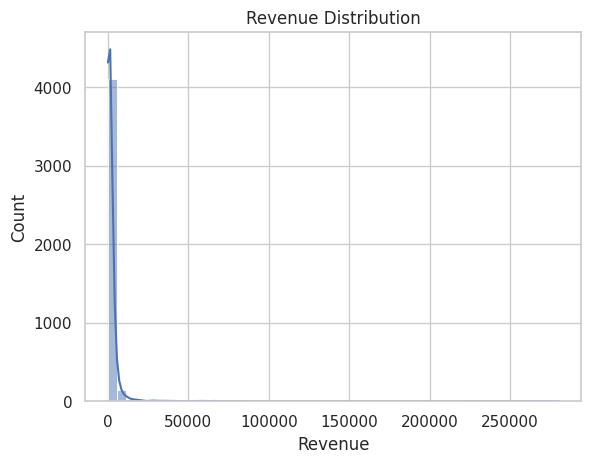

In [ ]:
sns.histplot(customer_data['Revenue'], bins=50, kde=True)

plt.title('Revenue Distribution')
plt.show()

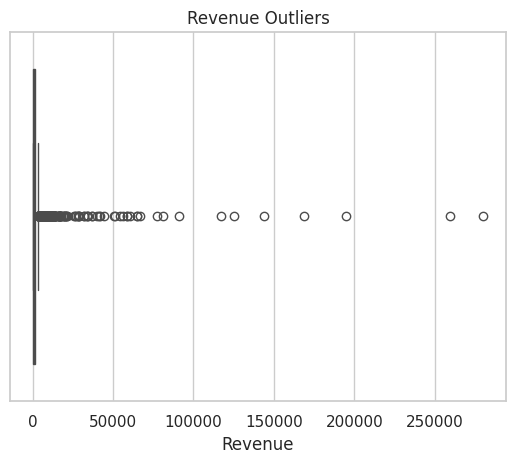

In [ ]:
sns.boxplot(x=customer_data['Revenue'])

plt.title('Revenue Outliers')
plt.show()

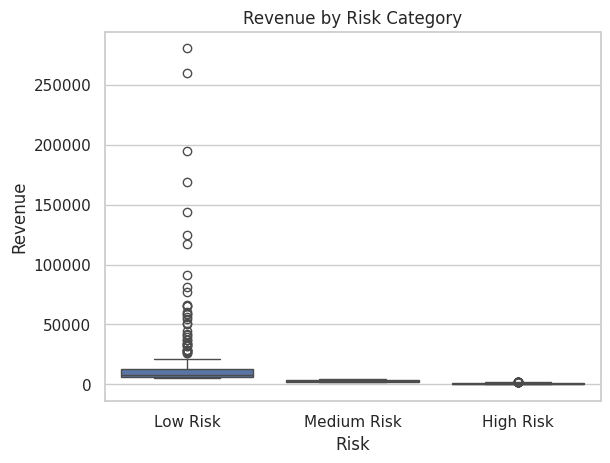

In [ ]:
sns.boxplot(x='Risk', y='Revenue', data=customer_data)

plt.title('Revenue by Risk Category')
plt.show()

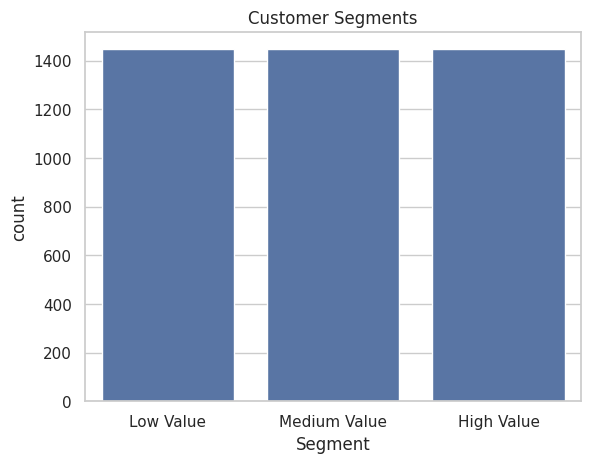

In [ ]:
sns.countplot(x='Segment', data=customer_data)

plt.title('Customer Segments')
plt.show()